In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from pyedflib import highlevel

from config import PATHS
from config.constants import SAMPLING_FREQUENCY_HZ

In [14]:
channels = ['Distal Channel', 'Proximal Channel']
n_ch = len(channels)


def load_info_from_pdir(pdir, interval_idx):
    """invalid_ivs, invalid_iv, full_signals = load_info_from_pdir(pdir, interval_idx)"""
    invalid_ivs = pd.read_pickle(pdir.invalid_edf_intervals.pickle)[["file_name", "start_idx", "end_idx"]]
    invalid_iv = invalid_ivs.iloc[interval_idx]
    file_name = invalid_iv.file_name
    full_signals, _, _ = highlevel.read_edf(str(pdir.edf_dir / file_name))
    return invalid_ivs, invalid_iv, full_signals


def calc_padded_artifact_interval(invalid_iv, full_n_samples, pad_samples):
    """left, right, rel_arti_start_idx, rel_arti_end_idx = calc_padded_artifact_interval(invalid_iv, full_n_samples, pad_samples)"""
    abs_start_idx, abs_end_idx = int(invalid_iv.start_idx), int(invalid_iv.end_idx)

    # Clip to file boundaries
    left = max(0, abs_start_idx - pad_samples)
    right = min(full_n_samples, abs_end_idx + pad_samples)

    # Relative indexes in the window
    rel_arti_start_idx = abs_start_idx - left
    rel_arti_end_idx = abs_end_idx - left

    return left, right, rel_arti_start_idx, rel_arti_end_idx


def plot_one_artifact(axes, invalid_iv, full_signals, pad_samples=500):
    n_ch, full_n_samples = full_signals.shape  # expected 2 channels
    left, right, rel_arti_start_idx, rel_arti_end_idx  = calc_padded_artifact_interval(invalid_iv, full_n_samples, pad_samples)

    window_sigs = full_signals[:, left:right]  # Artifact signals and surrounding area
    n_ch, n_samples = window_sigs.shape

    arti_start_time, arti_end_time = rel_arti_start_idx / SAMPLING_FREQUENCY_HZ, rel_arti_end_idx / SAMPLING_FREQUENCY_HZ
    time_sec = np.arange(n_samples) / SAMPLING_FREQUENCY_HZ

    for ch_i, ax in enumerate(axes):
        ax.axvspan(arti_start_time, arti_end_time, color='red', alpha=0.5, linewidth=1)  # Artifact region
        ax.plot(time_sec, window_sigs[ch_i, :], color="black", linewidth=0.45)  # Signal

    return axes


def plot_one_artifact_from_pdir(axes, pdir, interval_idx=0, pad_samples=500):
    _, invalid_iv, full_signals = load_info_from_pdir(pdir, interval_idx)
    axes = plot_one_artifact(axes, invalid_iv, full_signals, pad_samples)
    return axes


def add_row_titles(fig, axes, row_titles, pad=0.01):
    axes = np.atleast_2d(axes)  # handles edge cases like 1 column
    for r, title in enumerate(row_titles):
        pos_left = axes[r, 0].get_position()
        pos_right = axes[r, -1].get_position()

        x_center = (pos_left.x0 + pos_right.x1) / 2
        y_top = pos_left.y1 + pad

        fig.text(x_center, y_top, title, ha="center", va="bottom", fontweight="bold")


def plot_multiple_artifacts(pdir, iv_idxs, pad_samples: list[int]):
    width_ratios = []
    for iv_idx, pad in zip(iv_idxs, pad_samples):
        invalid_ivs, invalid_iv, full_signals = load_info_from_pdir(pdir, iv_idx)
        left, right, rel_arti_start_idx, rel_arti_end_idx = calc_padded_artifact_interval(invalid_iv, full_signals.shape[1], pad)
        width_ratios.append(right - left) # number of samples in the window

    fig, axes = plt.subplots(
        nrows=n_ch,
        ncols=len(iv_idxs),
        sharey=True,
        figsize=(15, 5),
        gridspec_kw={'width_ratios': width_ratios},
    )

    for i, (iv_idx, pad) in enumerate(zip(iv_idxs, pad_samples)):
        invalid_ivs, invalid_iv, full_signals = load_info_from_pdir(pdir, iv_idx)

        plot_one_artifact(axes[:, i], invalid_iv, full_signals, pad)

    for ax in axes[:-1, :].ravel():
        ax.tick_params(axis='x', which='both', labelbottom=False)

    fig.supylabel('Voltage ($\mu$V)')
    fig.supxlabel('time (s)')

    add_row_titles(fig, axes, channels)
    return fig

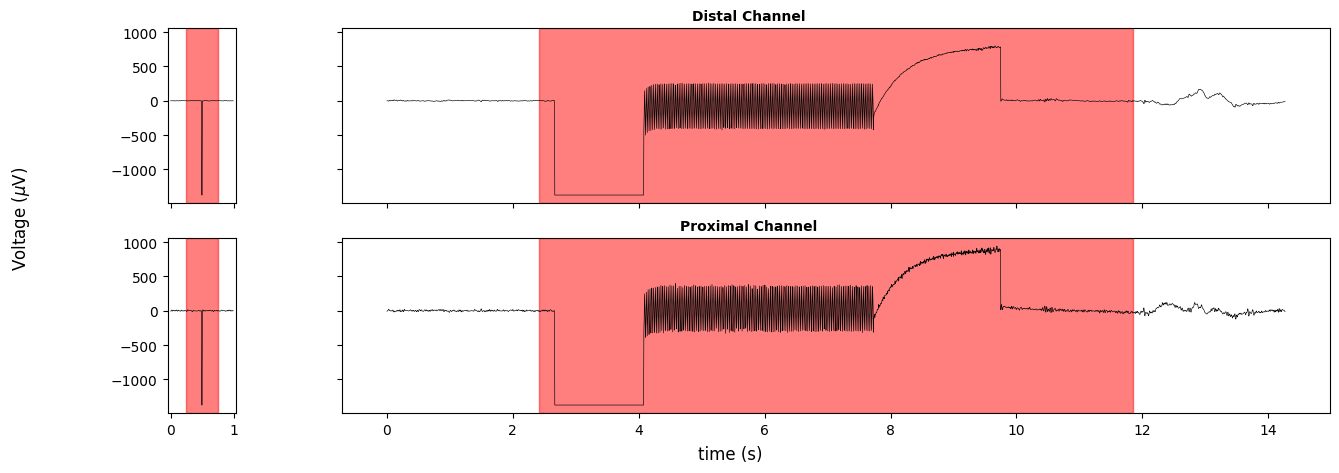

In [15]:
# Make the final plot
pdir = PATHS.patient_dirs(include_fake_ptnts=False)[0]
fig = plot_multiple_artifacts(pdir, iv_idxs=[1, 6], pad_samples=[50, 500])
fig.show()

abs_start_idx=901024, abs_end_idx=901130


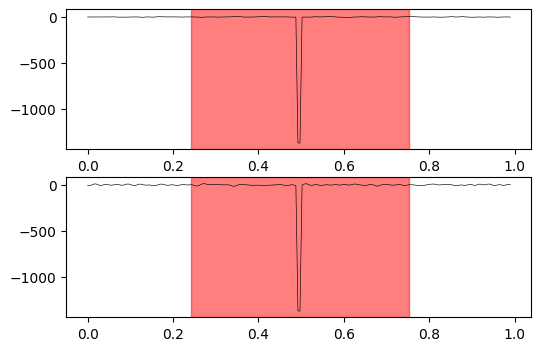

In [45]:
fig, axes = plt.subplots(nrows=n_ch, ncols=1, sharey=True, figsize=(6, 4))
plot_one_artifact(axes, pdir, interval_idx=1, pad_samples=50)
fig.show()

abs_start_idx=687381, abs_end_idx=689336


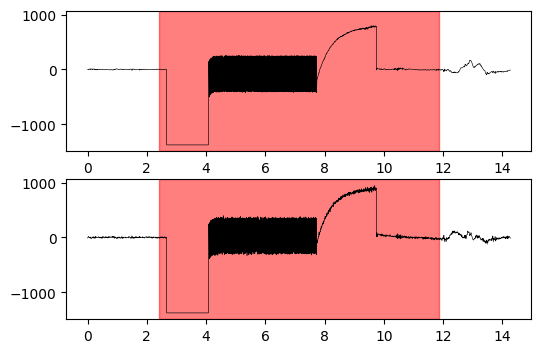

In [46]:
fig, axes = plt.subplots(nrows=n_ch, ncols=1, sharey=True, figsize=(6, 4))
plot_one_artifact(axes, pdir, interval_idx=6, pad_samples=500)
fig.show()

abs_start_idx=0, abs_end_idx=13128
abs_start_idx=901024, abs_end_idx=901130
abs_start_idx=1606723, abs_end_idx=1611288
abs_start_idx=0, abs_end_idx=1506
abs_start_idx=4471678, abs_end_idx=4471821
abs_start_idx=4471834, abs_end_idx=4472028
abs_start_idx=687381, abs_end_idx=689336
abs_start_idx=713578, abs_end_idx=719566
abs_start_idx=3337855, abs_end_idx=3339945
abs_start_idx=0, abs_end_idx=1800
abs_start_idx=4471806, abs_end_idx=4472028
abs_start_idx=0, abs_end_idx=466
abs_start_idx=4471846, abs_end_idx=4472028
abs_start_idx=1502789, abs_end_idx=1503234
abs_start_idx=0, abs_end_idx=3690
abs_start_idx=4481486, abs_end_idx=4481550
abs_start_idx=4471856, abs_end_idx=4472028
abs_start_idx=632150, abs_end_idx=639423
abs_start_idx=0, abs_end_idx=1506
abs_start_idx=2686560, abs_end_idx=2686666


/tmp/ipykernel_2927231/1179640609.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(nrows=n_ch, ncols=1, sharey=True, figsize=(6, 4))


abs_start_idx=4052976, abs_end_idx=4053082
abs_start_idx=4104412, abs_end_idx=4106259
abs_start_idx=0, abs_end_idx=1554
abs_start_idx=4471750, abs_end_idx=4471821
abs_start_idx=0, abs_end_idx=466
abs_start_idx=910820, abs_end_idx=921978
abs_start_idx=0, abs_end_idx=9894
abs_start_idx=1765820, abs_end_idx=1766952
abs_start_idx=0, abs_end_idx=1506
abs_start_idx=4471816, abs_end_idx=4472028
abs_start_idx=0, abs_end_idx=466
abs_start_idx=1131792, abs_end_idx=1131898
abs_start_idx=2523376, abs_end_idx=2524365
abs_start_idx=0, abs_end_idx=1506
abs_start_idx=21296, abs_end_idx=21402
abs_start_idx=2008810, abs_end_idx=2008916
abs_start_idx=3375226, abs_end_idx=3375332
abs_start_idx=4480780, abs_end_idx=4480929
abs_start_idx=0, abs_end_idx=466
abs_start_idx=1763868, abs_end_idx=1763974
abs_start_idx=4471856, abs_end_idx=4472028
abs_start_idx=645890, abs_end_idx=645996
abs_start_idx=3378722, abs_end_idx=3378828
abs_start_idx=4471854, abs_end_idx=4472028
abs_start_idx=3676854, abs_end_idx=3676960

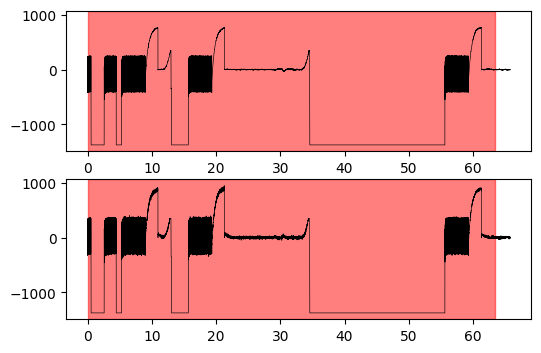

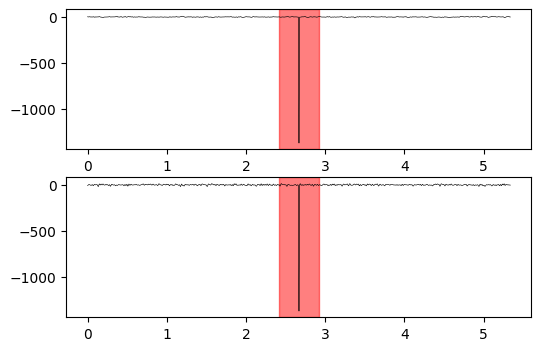

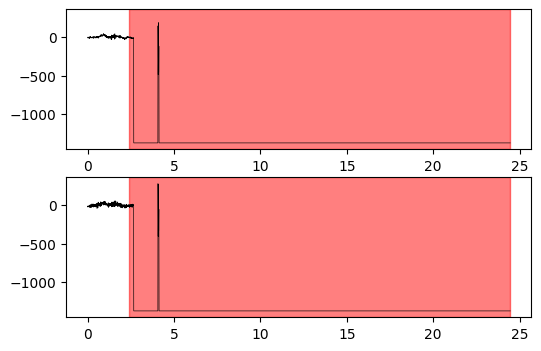

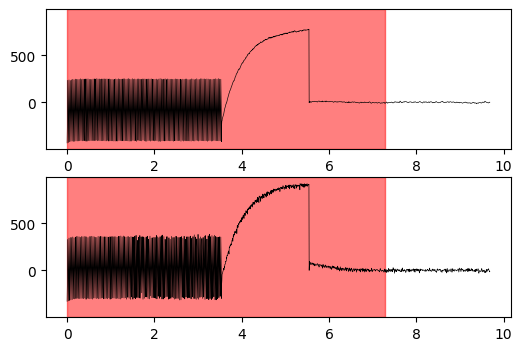

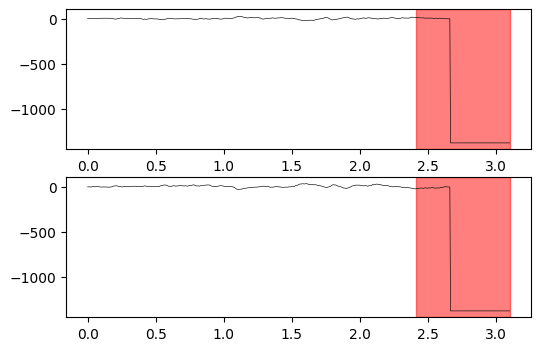

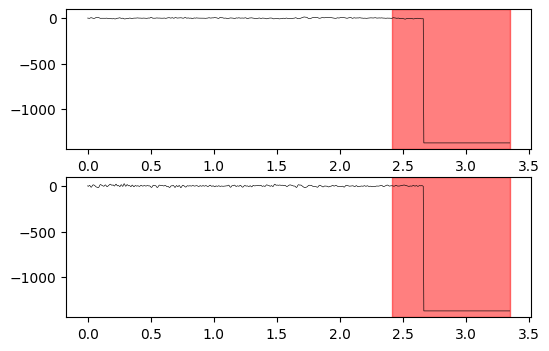

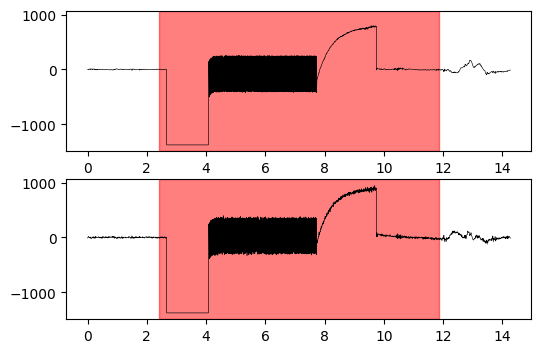

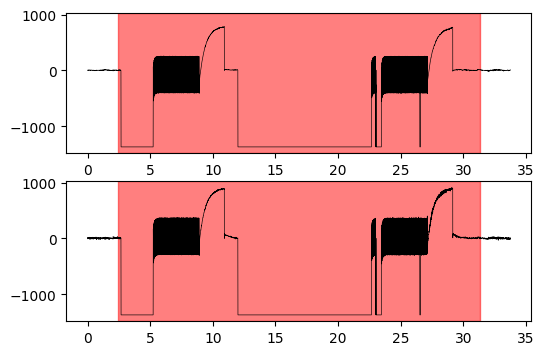

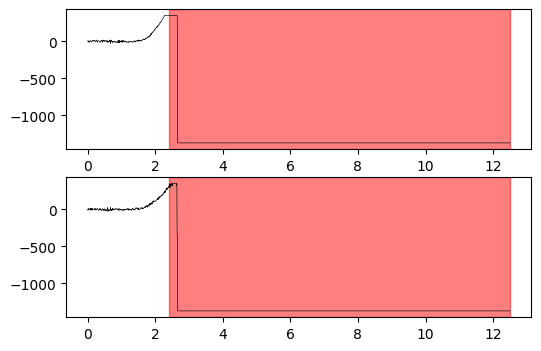

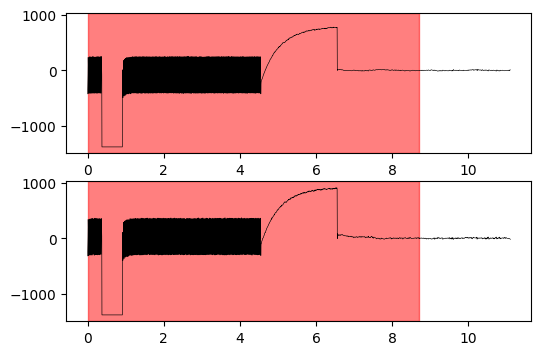

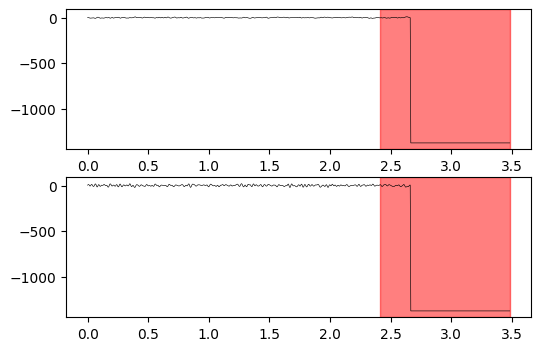

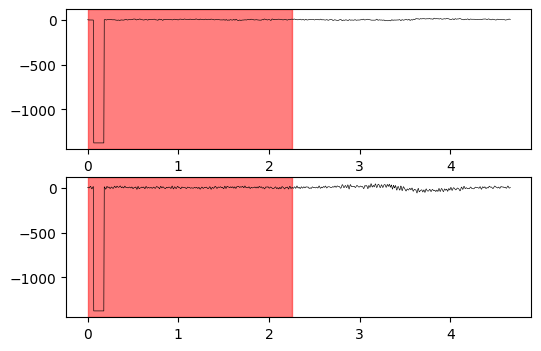

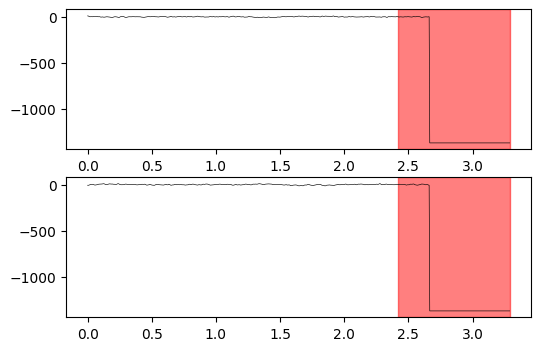

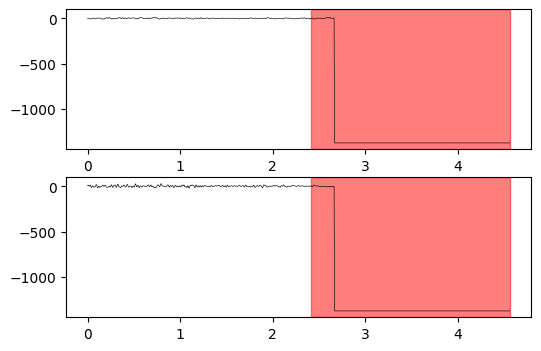

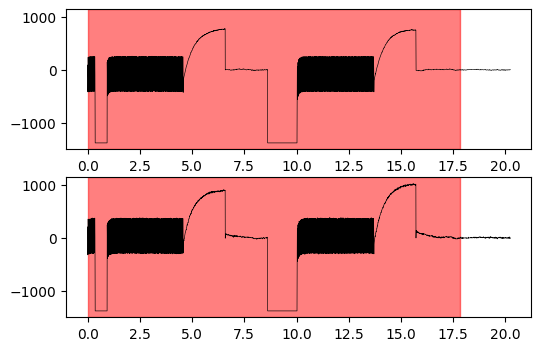

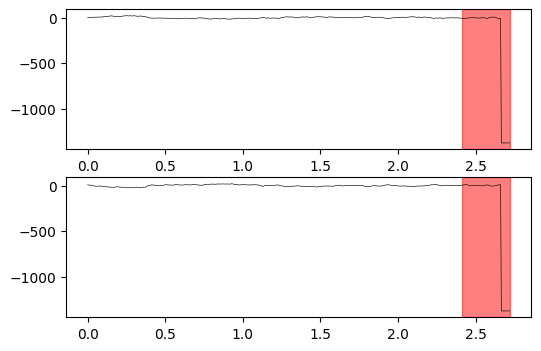

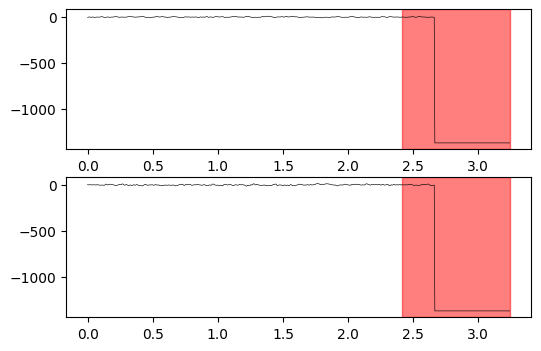

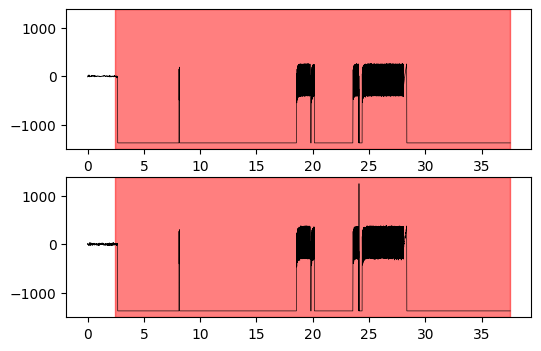

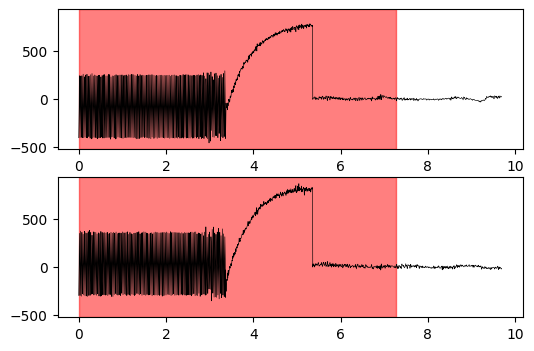

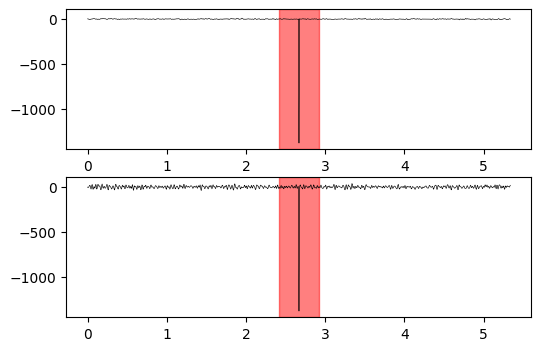

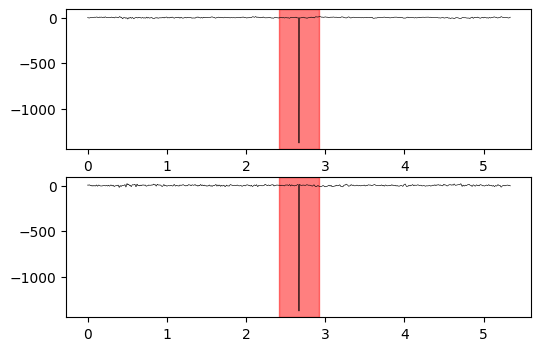

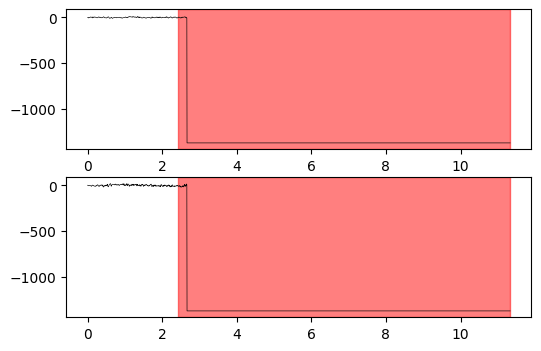

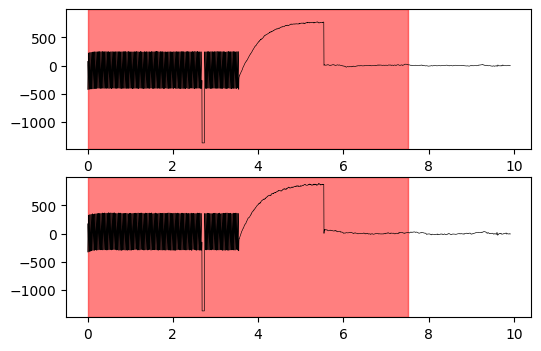

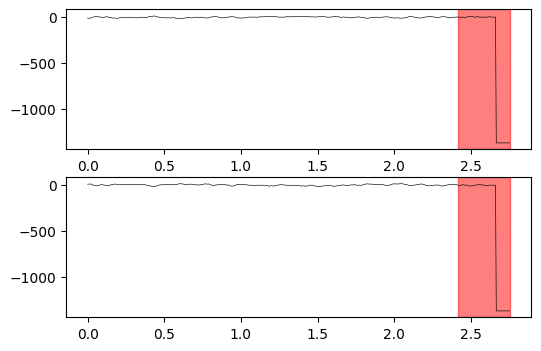

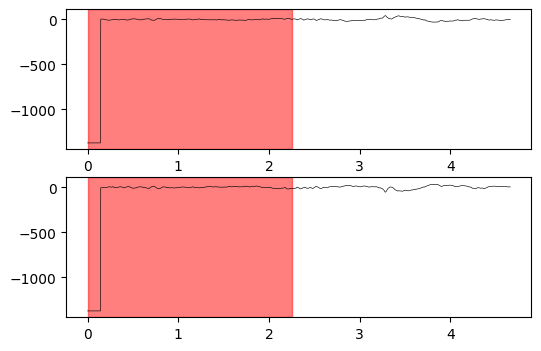

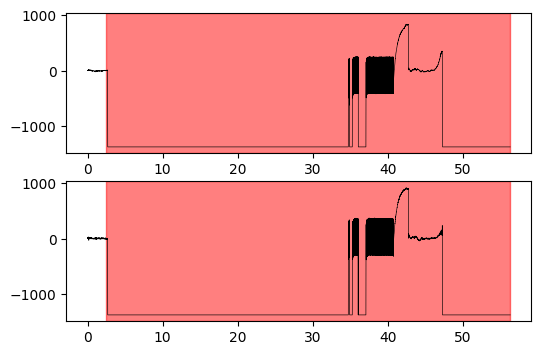

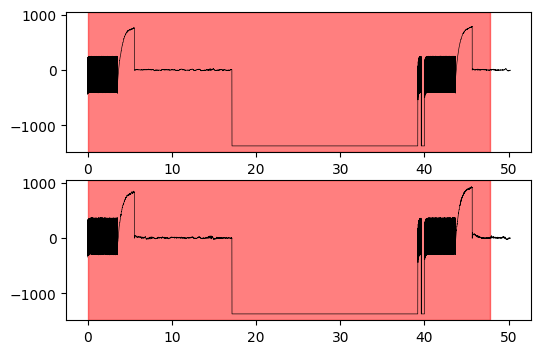

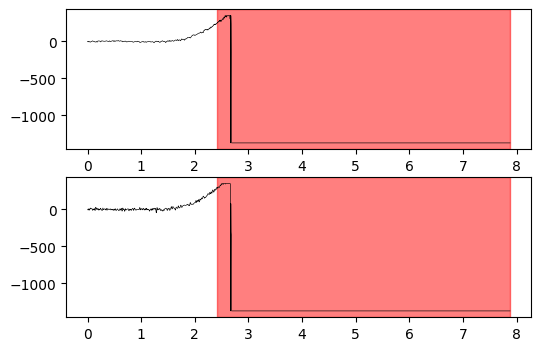

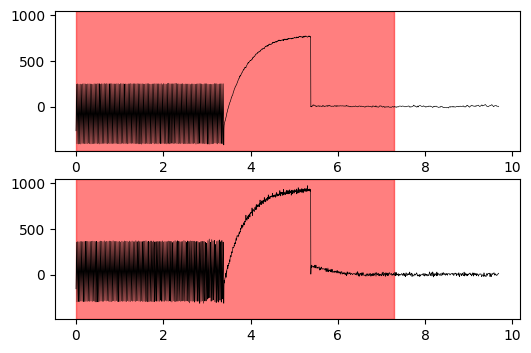

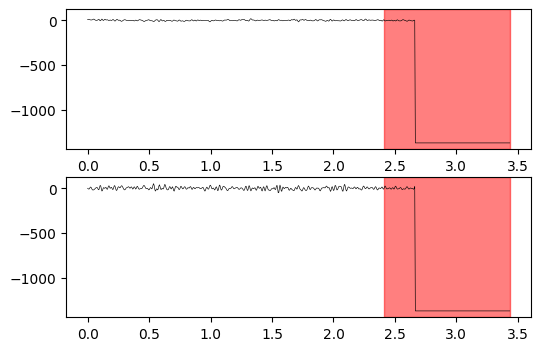

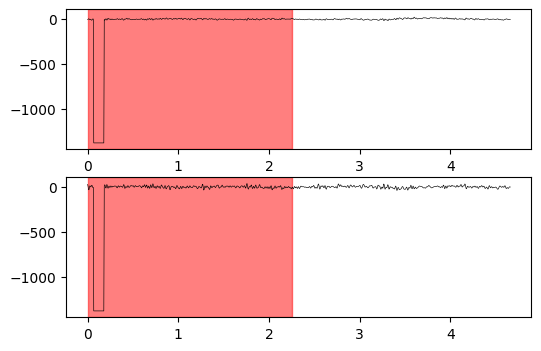

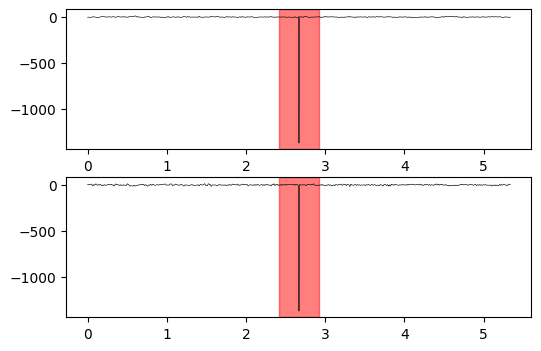

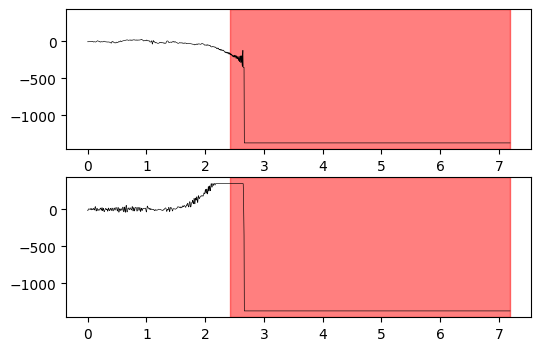

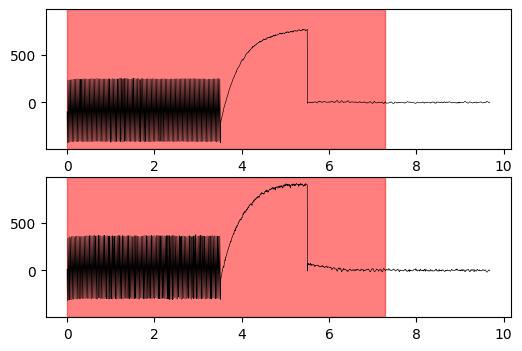

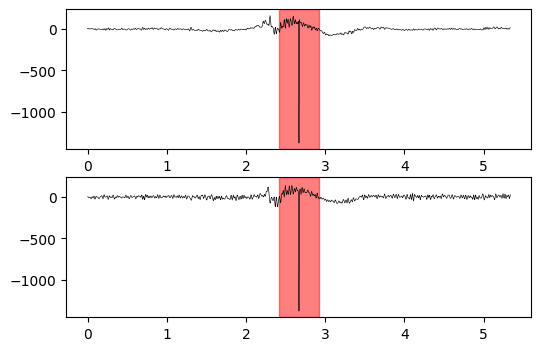

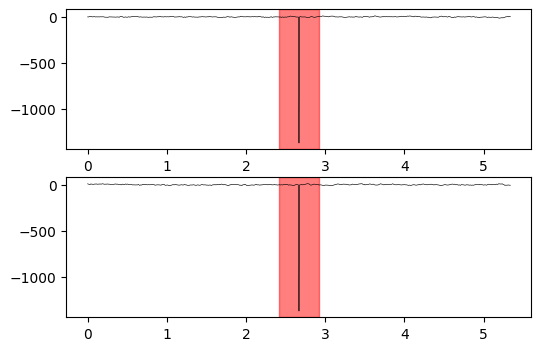

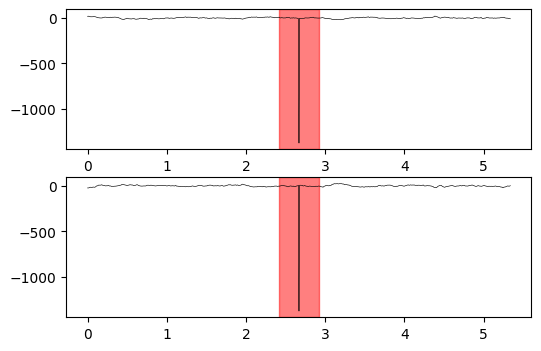

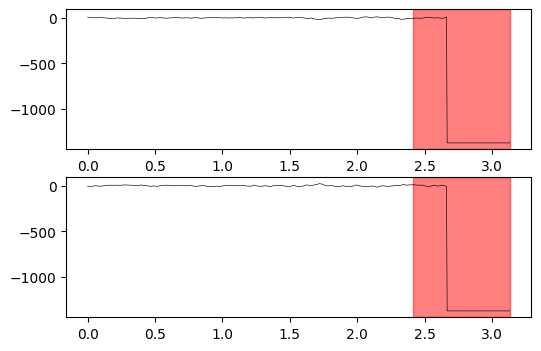

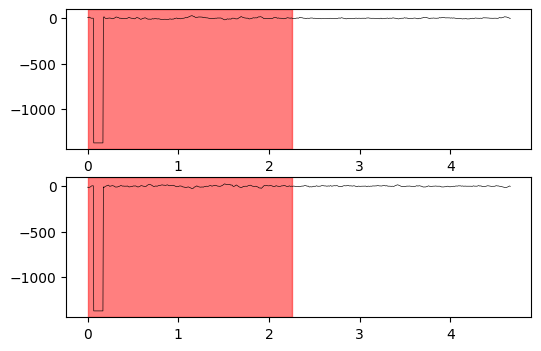

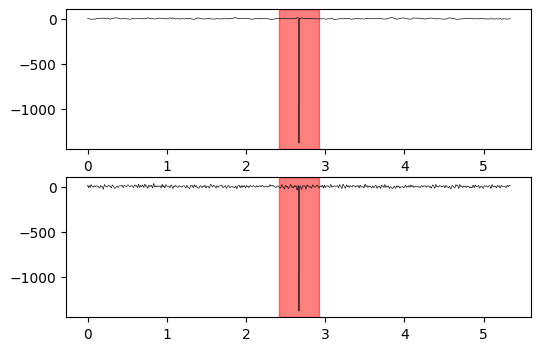

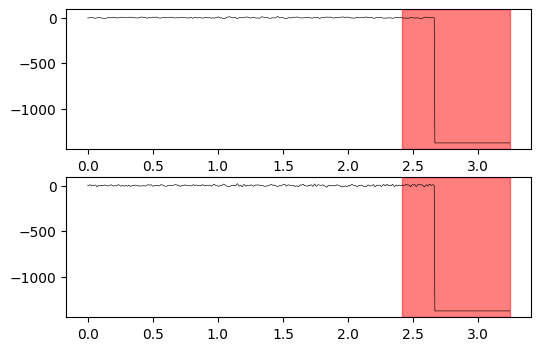

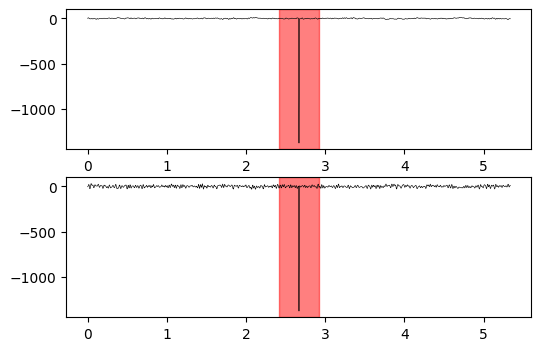

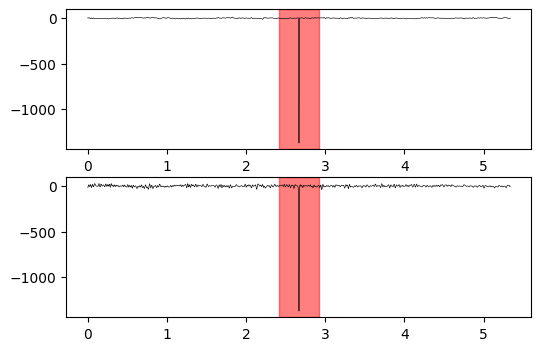

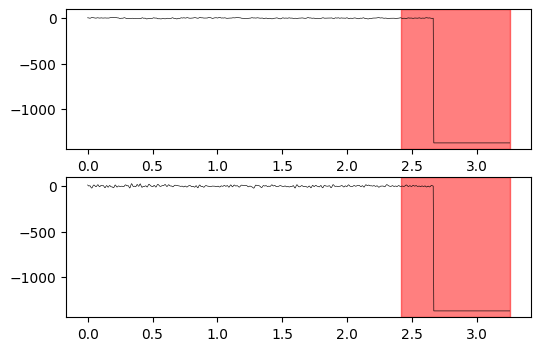

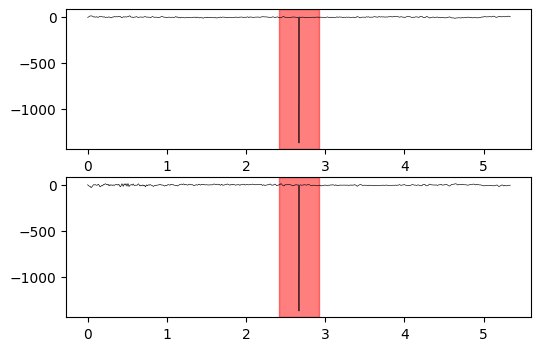

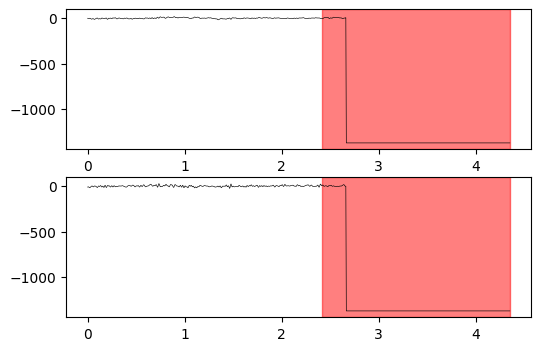

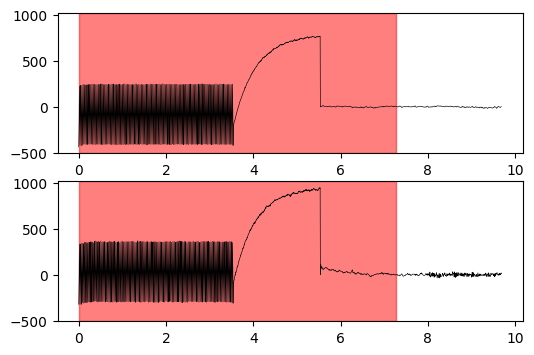

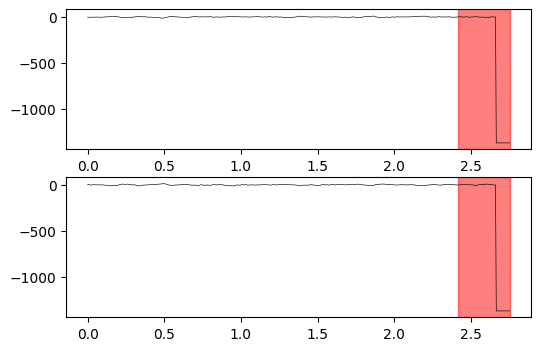

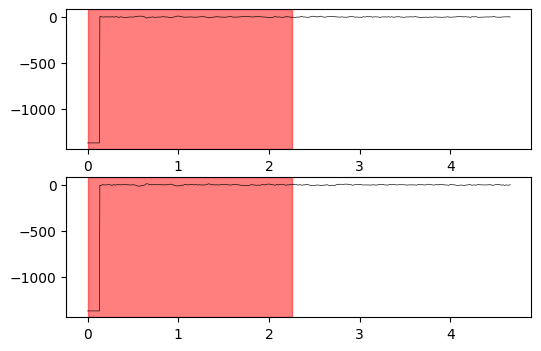

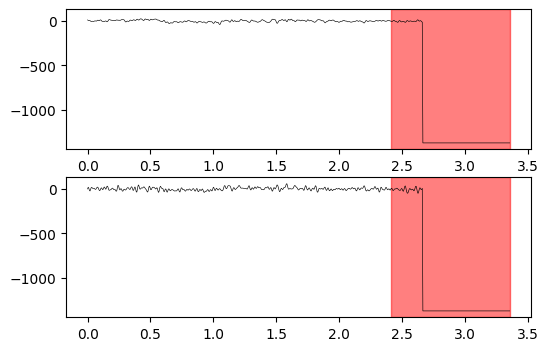

In [47]:

# examples = range(50)
examples = [1, 6]

for iv_idx in range(50):
    fig, axes = plt.subplots(nrows=n_ch, ncols=1, sharey=True, figsize=(6, 4))
    plot_one_artifact(axes, pdir, interval_idx=iv_idx, pad_samples=500)
    fig.show()